# Tutorial 8: Reinforcement Learning II
In this part of the tutorial you will implement Deep Q-Networks (DQN) to train an agent in a continuous state space environment. You will be tasked to complete parts of the code given the algorithms you learnt in the lecture. To gain a deeper understanding of these algorithms you will then play around with different parameters and observe the impact on performance and behaviour of the agent.


## Flappy Bird

![flappy_bird.gif](https://github.com/Talendar/flappy-bird-gym/raw/main/imgs/yellow_bird_playing.gif?raw=true)

---

This is a an OpenAI gym implementation the Flappy Bird game. The goal is to collect as much rewards by carefully maneuvering between two pipes. Flying into the pipes or the ground causes the game to end. The state space is continuous and the action space is discrete.

We can instantiate the environment as follows:


```
env = flappy_bird_gym.make("FlappyBird-v0", audio_on=False)
```


### Action Space

*   0: Do nothing
*   1: Flap

### Observation Space
Observations are an array [*x*, *y*] where *x* is the horizontal distance to the next pipe and *y* is the difference between the player's y position and the next pipe gap's y position.

###Rewards
The rewards output by the flappy bird gym environment are simply 1 for each time step that the agent is alive. Instead we use [reward shaping](https://gibberblot.github.io/rl-notes/single-agent/reward-shaping.html) to provide intermediate rewards to nudge the agent towards good behaviour, i.e. guiding it towards the gap in the pipe:
*   Reward at each time step: 1 - *abs(y)*
*   Crashing into pipe or ground: -50


### Interacting with the Environment
We can sample actions randomly, get the agent to perform that action and then observe how the environment state changes:
```
state = env.reset()  # this needs to be called once at the start before sending any actions
action = env.action_space.sample()
state, reward, done, info = env.step(action)
```


---



Before we can execute any code we first need to install the following packages:

In [ ]:
!apt-get update
!apt-get install -y xvfb
!pip install gym==0.26.2 pyvirtualdisplay pygame torch > /dev/null 2>&1
!pip install git+https://github.com/fredsukkar/flappy-bird-gym
!apt-get install -y python-opengl ffmpeg > /dev/null 2>&1

Now import the necessary packages and following helper functions (just execute as is):

**NOTE:** we will be mounting your google drive so that we can save our trained model and load it later. A pop-up window will ask you to give the notebook a few permissions, you will need to accept them all in order to save/load your network models.

In [ ]:
import gym
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
from pyvirtualdisplay import Display
from IPython.display import HTML
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import math
from collections import defaultdict
import pickle
from IPython.display import clear_output
import torch
import random
import flappy_bird_gym
from google.colab import drive
drive.mount('/content/drive')

display = Display(visible=0, size=(400, 300))
display.start()

def display_video(frames, framerate=30):
  """Generates video from `frames`.

  Args:
    frames (ndarray): Array of shape (n_frames, height, width, 3).
    framerate (int): Frame rate in units of Hz.

  Returns:
    Display object.
  """
  print("num frames: ", len(frames))
  print("flight time: ", len(frames) / 30.0)
  height, width, _ = frames[0].shape
  dpi = 70
  orig_backend = matplotlib.get_backend()
  matplotlib.use('Agg')  # Switch to headless 'Agg' to inhibit figure rendering.
  fig, ax = plt.subplots(1, 1, figsize=(width / dpi, height / dpi), dpi=dpi)
  matplotlib.use(orig_backend)  # Switch back to the original backend.
  ax.set_axis_off()
  ax.set_aspect('equal')
  ax.set_position([0, 0, 1, 1])
  im = ax.imshow(frames[0])
  def update(frame):
    im.set_data(frame)
    return [im]
  interval = 1000/framerate
  anim = animation.FuncAnimation(fig=fig, func=update, frames=frames,
                                  interval=interval, blit=True, repeat=False)
  return HTML(anim.to_html5_video())

Mounted at /content/drive


# Deep Q-Networks (DQN)

Let us now try to implement a Deep Q network. Since our state space is continous we can no longer use a look up table to represent q-values. Instead we learn a q-function approximator to learn this mapping which aims to generalise over all states. The main difference between standard q-learning is in lines 6 and 7 in the pseudocode. Here the q-values are predicted by taking a forward pass through the q-function approximator (we will use a neural network for this) and then we back propagate the error between the current estimated q-value and the target q-value we estimated from interacting with the environment, thus updating the neural network weights to better predict the true q-values. This is similar to classification learning except that we are collecting q-values in an unsupervised manner!

Here is the pseudocode from the DQN paper (note that instead of using images here we use the state directly - but might be an interesting idea for your final project!):

![DQN_algorithm.png](https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit4/sampling-training.jpg)

*The Deep Q-Learning Algorithm (Source: https://huggingface.co/learn/deep-rl-course/unit3/deep-q-algorithm)*

---

Recall from the lecture:
- DQN utilises two separate networks, a **policy network ($Q$)** and **target network ($\hat{Q}$)**. $Q$ is used to sample actions and produce q-value estimate. $\hat{Q}$ is used for target q-values and is updated slowly to stabilise learning (so we are not chasing constantly changing q-values).
- A **replay memory** which decorrelates samples and greatly increases training stability.


Below we will implement the DQN algorithm. Fill in the missing lines of code surrounded by comments.


In [ ]:
# Hyper parameters that will be used in the DQN algorithm

EPISODES = 2500                 # number of episodes to run the training for
LEARNING_RATE = 0.00025         # the learning rate for optimising the neural network weights
MEM_SIZE = 50000                # maximum size of the replay memory - will start overwritting values once this is exceed
REPLAY_START_SIZE = 10000       # The amount of samples to fill the replay memory with before we start learning
BATCH_SIZE = 32                 # Number of random samples from the replay memory we use for training each iteration
GAMMA = 0.99                    # Discount factor
EPS_START = 0.1                 # Initial epsilon value for epsilon greedy action sampling
EPS_END = 0.0001                # Final epsilon value
EPS_DECAY = 4 * MEM_SIZE        # Amount of samples we decay epsilon over
MEM_RETAIN = 0.1                # Percentage of initial samples in replay memory to keep - for catastrophic forgetting
NETWORK_UPDATE_ITERS = 5000     # Number of samples 'C' for slowly updating the target network \hat{Q}'s weights with the policy network Q's weights

FC1_DIMS = 128                   # Number of neurons in our MLP's first hidden layer
FC2_DIMS = 128                   # Number of neurons in our MLP's second hidden layer

# metrics for displaying training status
best_reward = 0
average_reward = 0
episode_history = []
episode_reward_history = []
np.bool = np.bool_

Here are the DQN classes that implement the replay buffer and network weight updates.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# for creating the policy and target networks - same architecture
class Network(torch.nn.Module):
    def __init__(self, env):
        super().__init__()
        self.input_shape = env.observation_space.shape
        self.action_space = env.action_space.n

        # build an MLP with 2 hidden layers
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(*self.input_shape, FC1_DIMS),   # input layer
            torch.nn.ReLU(),     # this is called an activation function
            torch.nn.Linear(FC1_DIMS, FC2_DIMS),    # hidden layer
            torch.nn.ReLU(),     # this is called an activation function
            torch.nn.Linear(FC2_DIMS, self.action_space)    # output layer
            )

        self.optimizer = optim.Adam(self.parameters(), lr=LEARNING_RATE)
        self.loss = nn.MSELoss()  # loss function

    def forward(self, x):
        return self.layers(x)

# handles the storing and retrival of sampled experiences
class ReplayBuffer:
    def __init__(self, env):
        self.mem_count = 0
        self.states = np.zeros((MEM_SIZE, *env.observation_space.shape),dtype=np.float32)
        self.actions = np.zeros(MEM_SIZE, dtype=np.int64)
        self.rewards = np.zeros(MEM_SIZE, dtype=np.float32)
        self.states_ = np.zeros((MEM_SIZE, *env.observation_space.shape),dtype=np.float32)
        self.dones = np.zeros(MEM_SIZE, dtype=np.bool)

    def add(self, state, action, reward, state_, done):
        # if memory count is higher than the max memory size then overwrite previous values
        if self.mem_count < MEM_SIZE:
            mem_index = self.mem_count
        else:
            mem_index = int(self.mem_count % ((1-MEM_RETAIN) * MEM_SIZE) + (MEM_RETAIN * MEM_SIZE))  # avoid catastrophic forgetting, retain first 10% of replay buffer

        self.states[mem_index]  = state
        self.actions[mem_index] = action
        self.rewards[mem_index] = reward
        self.states_[mem_index] = state_
        self.dones[mem_index] =  1 - done

        self.mem_count += 1

    # returns random samples from the replay buffer, number is equal to BATCH_SIZE
    def sample(self):
        MEM_MAX = min(self.mem_count, MEM_SIZE)
        batch_indices = np.random.choice(MEM_MAX, BATCH_SIZE, replace=True)

        states  = self.states[batch_indices]
        actions = self.actions[batch_indices]
        rewards = self.rewards[batch_indices]
        states_ = self.states_[batch_indices]
        dones   = self.dones[batch_indices]

        return states, actions, rewards, states_, dones

class DQN_Solver:
    def __init__(self, env):
        self.memory = ReplayBuffer(env)
        self.policy_network = Network(env)  # Q
        self.target_network = Network(env)  # \hat{Q}
        self.target_network.load_state_dict(self.policy_network.state_dict())  # initially set weights of Q to \hat{Q}
        self.learn_count = 0    # keep track of the number of iterations we have learnt for

    # epsilon greedy
    def choose_action(self, observation):
        # only start decaying epsilon once we actually start learning, i.e. once the replay memory has REPLAY_START_SIZE
        if self.memory.mem_count > REPLAY_START_SIZE:
            eps_threshold = EPS_END + (EPS_START - EPS_END) * \
                math.exp(-1. * self.learn_count / EPS_DECAY)
        else:
            eps_threshold = 1.0
        # if we rolled a value lower than epsilon sample a random action
        if random.random() < eps_threshold:
            return np.random.choice(np.array(range(2)), p=[0.9,0.1])    # sample random action with set priors (if we flap too much we will die too much at the start and learning will take forever)

        # otherwise policy network, Q, chooses action with highest estimated Q-value so far
        state = torch.tensor(observation).float().detach()
        state = state.unsqueeze(0)
        self.policy_network.eval()  # only need forward pass
        with torch.no_grad():       # so we don't compute gradients - save memory and computation
            q_values = self.policy_network(state)
        return torch.argmax(q_values).item()

    # main training loop
    def learn(self):
        states, actions, rewards, states_, dones = self.memory.sample()  # retrieve random batch of samples from replay memory
        states = torch.tensor(states , dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.long)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        states_ = torch.tensor(states_, dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.bool)
        batch_indices = np.arange(BATCH_SIZE, dtype=np.int64)

        self.policy_network.train(True)
        q_values = self.policy_network(states)                # get current q-value estimates (all actions) from policy network, Q
        q_values = q_values[batch_indices, actions]           # q values for sampled actions only

        self.target_network.eval()                            # only need forward pass
        with torch.no_grad():                                 # so we don't compute gradients - save memory and computation
            q_values_next = self.target_network(states_)      # target q-values for states_ for all actions (target network, \hat{Q})

        q_values_next_max = torch.max(q_values_next, dim=1)[0]  # max q values for next state

        q_target = rewards + GAMMA * q_values_next_max * dones  # our target q-value

        loss = self.policy_network.loss(q_target, q_values)     # compute loss between target (target network, \hat{Q}) and estimated q-values (policy network, Q)
        #compute gradients and update policy network Q weights
        self.policy_network.optimizer.zero_grad()
        loss.backward()
        self.policy_network.optimizer.step()
        self.learn_count += 1

        # set target network \hat{Q}'s weights to policy network Q's weights every C steps
        if  self.learn_count % NETWORK_UPDATE_ITERS == NETWORK_UPDATE_ITERS - 1:
            print("updating target network")
            self.update_target_network()

    def update_target_network(self):
        self.target_network.load_state_dict(self.policy_network.state_dict())

    def returning_epsilon(self):
        return self.exploration_rate


Let's train flappy bird with DQN

In [ ]:
env = flappy_bird_gym.make("FlappyBird-v0", audio_on=False)
# set manual seeds so we get same behaviour everytime - so that when you change your hyper parameters you can attribute the effect to those changes
env.action_space.seed(0)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
episode_batch_score = 0
episode_reward = 0
agent = DQN_Solver(env)  # create DQN agent
plt.clf()

for i in range(EPISODES):
    state = env.reset()  # this needs to be called once at the start before sending any actions
    while True:
        # sampling loop - sample random actions and add them to the replay buffer
        action = agent.choose_action(state)
        state_, reward, done, info = env.step(action)
        reward += -abs(state[1])
        if done == True:
          reward = -50
        agent.memory.add(state, action, reward, state_, done)

        # only start learning once replay memory reaches REPLAY_START_SIZE
        if agent.memory.mem_count > REPLAY_START_SIZE:
            agent.learn()

        state = state_
        episode_batch_score += reward
        episode_reward += reward

        if done:
            break

    episode_history.append(i)
    episode_reward_history.append(episode_reward)
    episode_reward = 0.0

    # save our model every batches of 100 episodes so we can load later. (note: you can interrupt the training any time and load the latest saved model when testing)
    if i % 100 == 0 and agent.memory.mem_count > REPLAY_START_SIZE:
        torch.save(agent.policy_network.state_dict(), "/content/drive/My Drive/Colab Notebooks/policy_network.pkl")
        print("average total reward per episode batch since episode ", i, ": ", episode_batch_score/ float(100))
        episode_batch_score = 0
    elif agent.memory.mem_count < REPLAY_START_SIZE:
        print("waiting for buffer to fill...")
        episode_batch_score = 0

plt.plot(episode_history, episode_reward_history)
plt.show()

waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting for buffer to fill...
waiting fo

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

Test your learnt policy. Try running your policy multiple times (everytime you execute this following block you will get a new flappy bird level), what happens and why?

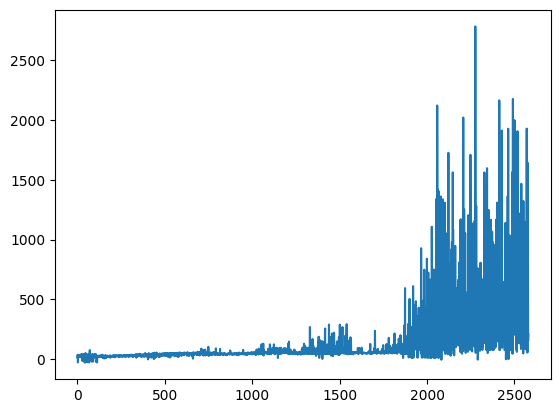

/usr/local/lib/python3.10/dist-packages/gym/utils/passive_env_checker.py:272: UserWarning: WARN: No render modes was declared in the environment (env.metadata['render_modes'] is None or not defined), you may have trouble when calling `.render()`.
  logger.warn(


num frames:  1320
flight time:  44.0


In [ ]:
plt.plot(episode_history, episode_reward_history)
plt.show()

env = flappy_bird_gym.make("FlappyBird-v0", audio_on=False)
agent = DQN_Solver(env)
agent.policy_network.load_state_dict(torch.load("/content/drive/My Drive/Colab Notebooks/policy_network.pkl"))
frames = []
state = env.reset()
agent.policy_network.eval()

while True:
    with torch.no_grad():
        q_values = agent.policy_network(torch.tensor(state, dtype=torch.float32))
    action = torch.argmax(q_values).item() # select action with highest predicted q-value
    state, reward, done, info = env.step(action)
    frames.append(np.fliplr(np.rot90(env.render(mode="rgb_array"), 3)))
    if done:
        break

env.close()

display_video(frames)

Things to try:
- What happens if you set the learning rate too high/ low?
- What happens if the replay buffer is too small?
- What happens if your batch size is too large/ small?
- What happens if you don't explore enough at the start of training (low EPS_DECAY)?
- What happens if you update the target network weights too slow/ fast?
- What happens if you don't retain a percantage of your replay memory's initial samples (catastrophic forgetting)?